In [1]:
# This notebook calculates scattering cross sections and kinematics for
# T2 and H2 using the optical approximation.
#
# WARNING - I do not recommend to use it; the large angle behaviour of the
# optical approximation is importantly incorrect. This issue needs more
# theoretical attention before we can use these methods.

In [2]:
import numpy as np
import pandas as pd
import constants
import sampling
import pylab as plt
from scipy.interpolate import interp1d
import opticalapprox
%matplotlib inline


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_47055/1446804474.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  datH2=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_47055/1446804474.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  datKr=pd.read_csv("./Data/OscStrengthKr.txt", skiprows=65,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_47055/1446804474.py:9: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='py

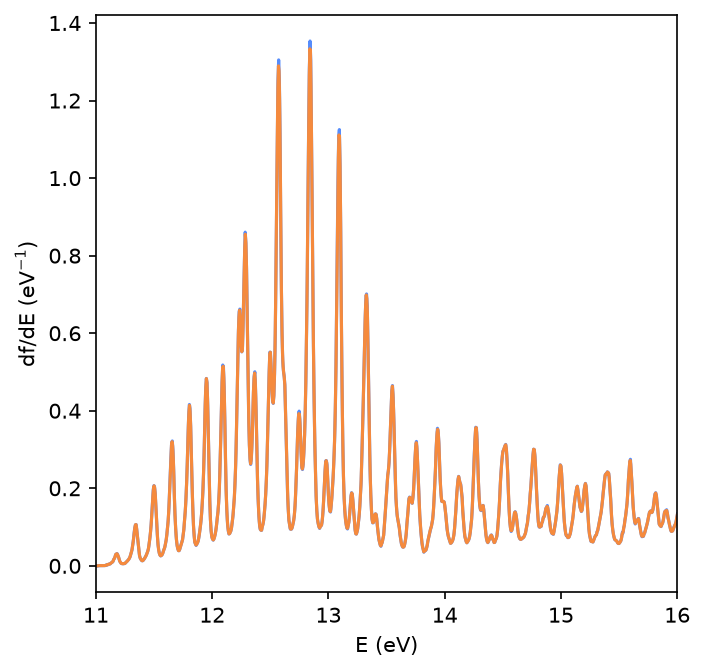

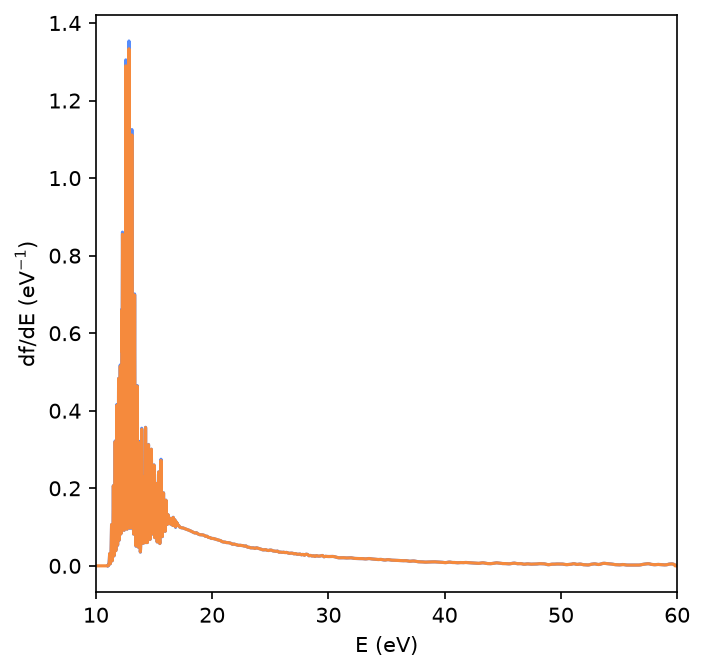

In [3]:

datH2=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrH2=interp1d(datH2['E'],datH2['dfdE'],fill_value=0,bounds_error=False,kind='linear')


datKr=pd.read_csv("./Data/OscStrengthKr.txt", skiprows=65,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrKr=interp1d(datKr['E'],datKr['dfdE'],fill_value=0,bounds_error=False,kind='linear')


datCO=pd.read_csv("./Data/OscStrengthCO.txt", skiprows=65,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrCO=interp1d(datCO['E'],datCO['dfdE'],fill_value=0,bounds_error=False,kind='linear')

datN2=pd.read_csv("./Data/OscStrengthN2.txt", skiprows=65,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrN2=interp1d(datN2['E'],datN2['dfdE'],fill_value=0,bounds_error=False,kind='linear')


plt.figure(figsize=(5,5),dpi=150)
plt.plot(datH2.E,datH2.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(11,16)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

plt.figure(figsize=(5,5),dpi=150)
plt.plot(datH2.E,datH2.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(10,60)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

In [4]:
pd.read_csv("./Data/OscStrengthKr.txt", skiprows=63,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)

/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_47055/1711121331.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  pd.read_csv("./Data/OscStrengthKr.txt", skiprows=63,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)


,E,dfdE
0,18.10907,0.388720
1,18.12608,0.387190
2,18.14309,0.389900
3,18.16010,0.386600
4,18.17711,0.390500
...,...,...
1011,35.30588,0.085453
1012,35.32288,0.085720
1013,35.33989,0.093816
1014,35.35690,0.089798


In [5]:
Ts=np.linspace(1e2,20e3,1000)
sigma_contH2=[opticalapprox.sig_oscstrength(T,OscStrH2,constants.mT*2) for T in Ts]
sigma_contKr=[opticalapprox.sig_oscstrength(T,OscStrKr,constants.mT*83/3) for T in Ts]
sigma_contCO=[opticalapprox.sig_oscstrength(T,OscStrCO,constants.mT*28/3) for T in Ts]
sigma_contN2=[opticalapprox.sig_oscstrength(T,OscStrN2,constants.mT*28/3) for T in Ts]



/Users/benjpjones/Documents/Work/Project8ElectronScattering/kinematics.py:12: RuntimeWarning: invalid value encountered in scalar power
  return 2*T/constants.R*movM**-2*(1-0.5*movM*E/T-(1-movM*E/T)**0.5)
/Users/benjpjones/Documents/Work/Project8ElectronScattering/kinematics.py:17: RuntimeWarning: invalid value encountered in scalar power
  return 2*T/constants.R*movM**-2*(1-0.5*movM*E/T+(1-movM*E/T)**0.5)
/Users/benjpjones/Documents/Work/Project8ElectronScattering/opticalapprox.py:21: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return (quad(ToInt, lnEovR_min, lnEovR_max)[0])


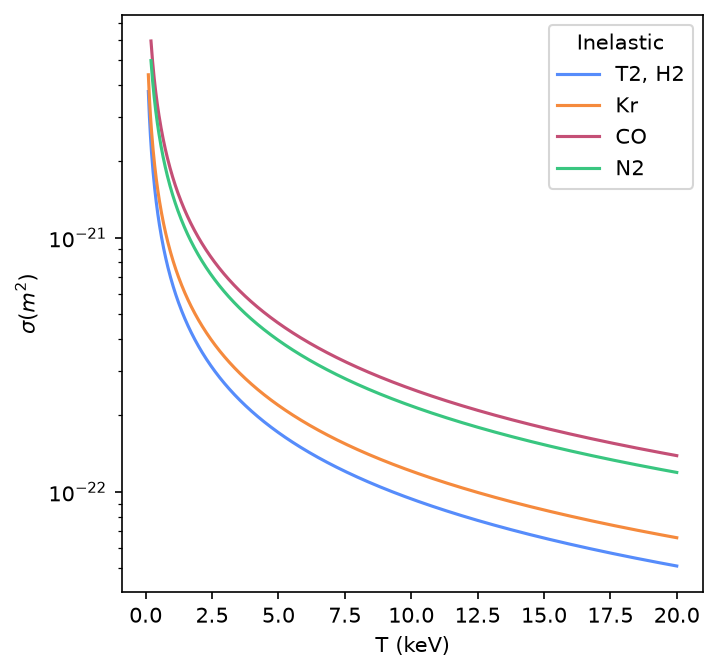

In [9]:
plt.figure(figsize=(5,5),dpi=150)
plt.plot(Ts/1000,sigma_contH2,'-',label='T2, H2')
plt.plot(Ts/1000,sigma_contKr,'-',label='Kr')
plt.plot(Ts/1000,sigma_contCO,'-',label='CO')
plt.plot(Ts/1000,sigma_contN2,'-',label='N2')

plt.legend(loc='upper right',title='Inelastic')
plt.semilogy()
plt.xlabel("T (keV)")
plt.ylabel(r"$\sigma (m^2)$")
plt.savefig("CrossSection.png",dpi=150,bbox_inches='tight')

In [11]:
dTsH2=[]
dThsH2=[]
dTsCO=[]
dThsCO=[]
dTsKr=[]
dThsKr=[]
dTsN2=[]
dThsN2=[]
for i in range(0,100000):
    dTH2,dThH2=opticalapprox.SampleKinematics(20e3,OscStrH2,constants.mT*2)
    dTsH2.append(dTH2)
    dThsH2.append(dThH2)
for i in range(0,100000):
    dTKr,dThKr=opticalapprox.SampleKinematics(20e3,OscStrKr,constants.mT*83/3)
    dTsKr.append(dTKr)
    dThsKr.append(dThKr)
for i in range(0,100000):
    dTCO,dThCO=opticalapprox.SampleKinematics(20e3,OscStrCO,constants.mT*28/3)
    dTsCO.append(dTCO)
    dThsCO.append(dThCO)
for i in range(0,100000):
    dTN2,dThN2=opticalapprox.SampleKinematics(20e3,OscStrN2,constants.mT*28/3)
    dTsN2.append(dTN2)
    dThsN2.append(dThN2)

/Users/benjpjones/Documents/Work/Project8ElectronScattering/opticalapprox.py:42: RuntimeWarning: invalid value encountered in arccos
  Theta = np.arccos(kinematics.getCosTheta(Ka2, T, dE))


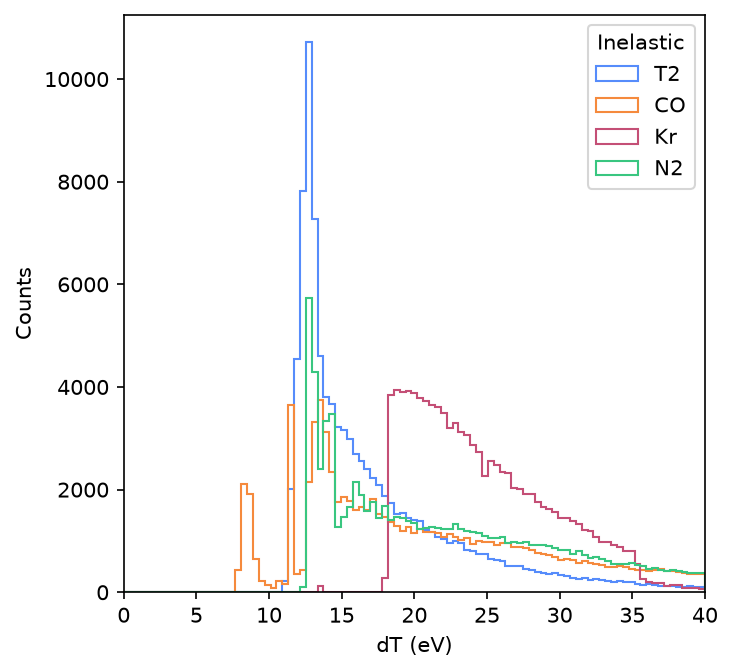

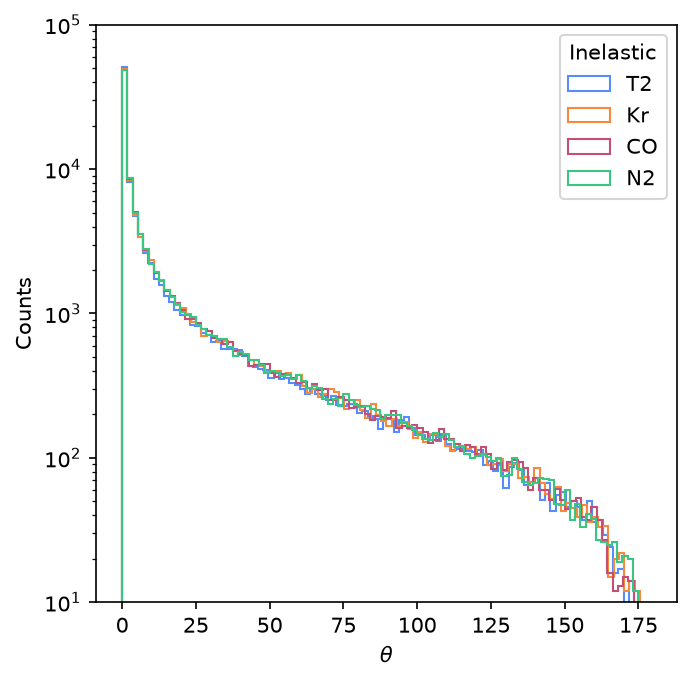

In [12]:

plt.figure(figsize=(5,5),dpi=150)
plt.hist(dTsH2,bins=np.linspace(0,40,100),histtype="step",label='T2')
plt.hist(dTsCO,bins=np.linspace(0,40,100),histtype="step",label='CO')
plt.hist(dTsKr,bins=np.linspace(0,40,100),histtype="step",label='Kr')
plt.hist(dTsN2,bins=np.linspace(0,40,100),histtype="step",label='N2')
plt.xlim(0,40)
plt.xlabel("dT (eV)")
plt.ylabel("Counts")
plt.legend(loc='upper right',title='Inelastic')
plt.show()

plt.figure(figsize=(5,5),dpi=150)
plt.hist(np.array(dThsH2)*180/np.pi,bins=100,histtype="step",label='T2')
plt.hist(np.array(dThsKr)*180/np.pi,bins=100,histtype="step",label='Kr')
plt.hist(np.array(dThsCO)*180/np.pi,bins=100,histtype="step",label='CO')
plt.hist(np.array(dThsN2)*180/np.pi,bins=100,histtype="step",label='N2')
plt.ylim(1e1,1e5)
plt.xlabel(r"$\theta$")
plt.ylabel("Counts")
plt.semilogy()
plt.legend(loc='upper right',title='Inelastic')
plt.show()



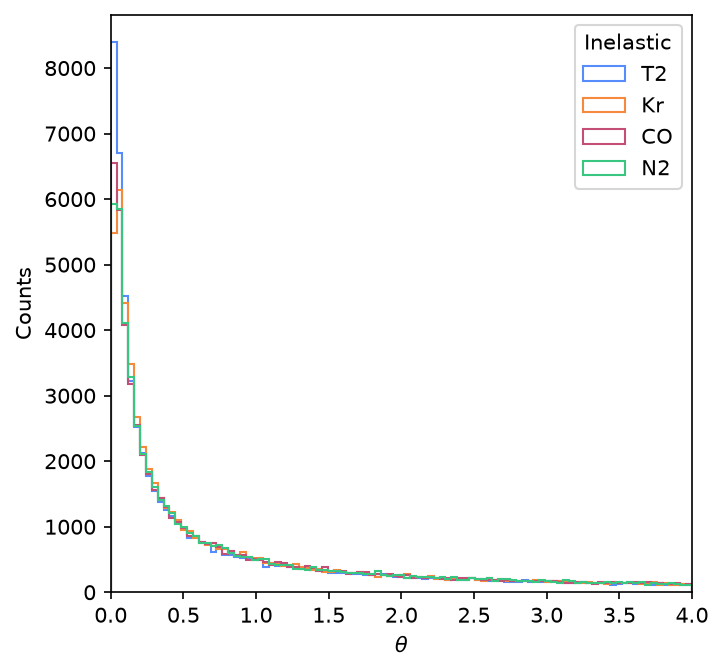

In [19]:
plt.figure(figsize=(5,5),dpi=150)
plt.hist(np.array(dThsH2)*180/np.pi,bins=np.linspace(0,4,100),histtype="step",label='T2')
plt.hist(np.array(dThsKr)*180/np.pi,bins=np.linspace(0,4,100),histtype="step",label='Kr')
plt.hist(np.array(dThsCO)*180/np.pi,bins=np.linspace(0,4,100),histtype="step",label='CO')
plt.hist(np.array(dThsN2)*180/np.pi,bins=np.linspace(0,4,100),histtype="step",label='N2')
plt.xlim(0,4)
plt.xlabel(r"$\theta$")
plt.ylabel("Counts")
plt.legend(loc='upper right',title='Inelastic')
plt.show()

In [ ]:
ElectronEnergy=18e3
Density0=20e3
#
for n in range(0,100):
    Distance, Theta, dT, CollisionTypeName = sampling.GetNextCollision(TotalCrossSections,KinematicsFunctions,T=ElectronEnergy,Density=Density0)

    print("Collision of type <" + str(CollisionTypeName) + "> after distance " + str(round(Distance,2)) + " m")
    print("   Energy loss dT = " + str(round(dT,3)) + " eV  angle  dTh = "+str(round(Theta*180/np.pi,2))+ " deg")
    print("   New electron E = " + str(ElectronEnergy))
    print()

    ElectronEnergy = ElectronEnergy - dT